# DSM σ-Loss Analysis

Analyzes how the denoiser's loss (MSE as a function of noise level σ) evolves across training checkpoints.

Three data splits per checkpoint:
- **Train** (blue): in-distribution training samples
- **Test** (red): valid unseen samples satisfying the rule
- **Random** (gray): uniform ±1 (no rule)

A growing train/test gap signals memorization.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
FIGDIR   = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/sigma_loss_analysis"
SAVE_FIGS = True

os.makedirs(FIGDIR, exist_ok=True)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Constants ──────────────────────────────────────────────────────────────

SIGMA_BINS = [
    ("σ ∈ [0.002, 0.02]",  0.002,  0.02),
    ("σ ∈ [0.02, 0.2]",    0.02,   0.2),
    ("σ ∈ [0.2, 2]",       0.2,    2.0),
    ("σ ∈ [2, 20]",        2.0,   20.0),
    ("σ ∈ [20, 80]",      20.0,   80.0),
]

_zoom_edges = np.geomspace(0.2, 2.0, 8)
SIGMA_BINS_ZOOM = [
    (f"σ ∈ [{_zoom_edges[i]:.3f}, {_zoom_edges[i+1]:.3f}]",
     _zoom_edges[i], _zoom_edges[i+1])
    for i in range(len(_zoom_edges) - 1)
]

SPLIT_STYLES = {
    "train":  dict(color="#2166ac", lw=1.8, label="Train (in-dist)"),
    "test":   dict(color="#d73027", lw=1.8, label="Test (valid, unseen)"),
    "random": dict(color="#555555", lw=1.4, ls="--", label="Random ±1"),
}

ALL_EXPS = [
    "DiT_mini_rowK2_n6_N4096",
    "DiT_mini_rowK3_n6_N4096",
    "DiT_mini_rowVarK15_n6_N4096",
    "DiT_mini_rowVarK34_n6_N4096",
    "DiT_mini_rowVarK0246_n6_N4096",
    "DiT_mini_rowVarK3456_n6_N4096",
    "DiT_mini_globalK15_n6_N4096",
    "DiT_mini_globalK24_n6_N4096",
]
ALL_LABELS = ["rowK2", "rowK3", "varK15", "varK34", "varK0246", "varK3456", "globalK15", "globalK24"]

In [3]:
# ── Data loading ───────────────────────────────────────────────────────────

def load_sigma_data(exp_name):
    """Load all sigma_loss npz files for an experiment, sorted by epoch."""
    sigma_dir = os.path.join(SAVEROOT, exp_name, "sigma_loss")
    if not os.path.isdir(sigma_dir):
        raise FileNotFoundError(f"No sigma_loss dir: {sigma_dir}")
    records = []
    for fname in sorted(os.listdir(sigma_dir)):
        if not fname.endswith(".npz"):
            continue
        d = np.load(os.path.join(sigma_dir, fname), allow_pickle=True)
        if len(d["sigma_grid"]) < 10:
            continue
        records.append({
            "epoch":       int(d["meta_ckpt_epoch"]),
            "sigma_grid":  d["sigma_grid"],
            "loss_train":  d["loss_train"],
            "loss_test":   d["loss_test"],
            "loss_random": d["loss_random"],
            "std_train":   d["std_train"],
            "std_test":    d["std_test"],
            "std_random":  d["std_random"],
        })
    records.sort(key=lambda r: r["epoch"])
    return records


def bin_mean(loss, sigma_grid, smin, smax):
    mask = (sigma_grid >= smin) & (sigma_grid <= smax)
    return float(loss[mask].mean()) if mask.any() else np.nan


# Pre-load all data
all_data = {}
for exp in ALL_EXPS:
    try:
        all_data[exp] = load_sigma_data(exp)
        print(f"{exp}: {len(all_data[exp])} checkpoints")
    except FileNotFoundError:
        all_data[exp] = []
        print(f"{exp}: NOT FOUND")

DiT_mini_rowK2_n6_N4096: 39 checkpoints
DiT_mini_rowK3_n6_N4096: 39 checkpoints
DiT_mini_rowVarK15_n6_N4096: 39 checkpoints
DiT_mini_rowVarK34_n6_N4096: 39 checkpoints
DiT_mini_rowVarK0246_n6_N4096: 39 checkpoints


DiT_mini_rowVarK3456_n6_N4096: 39 checkpoints
DiT_mini_globalK15_n6_N4096: 39 checkpoints
DiT_mini_globalK24_n6_N4096: 39 checkpoints


## 1. Single-run evolution: rowK2

Loss in each σ bin vs training step.

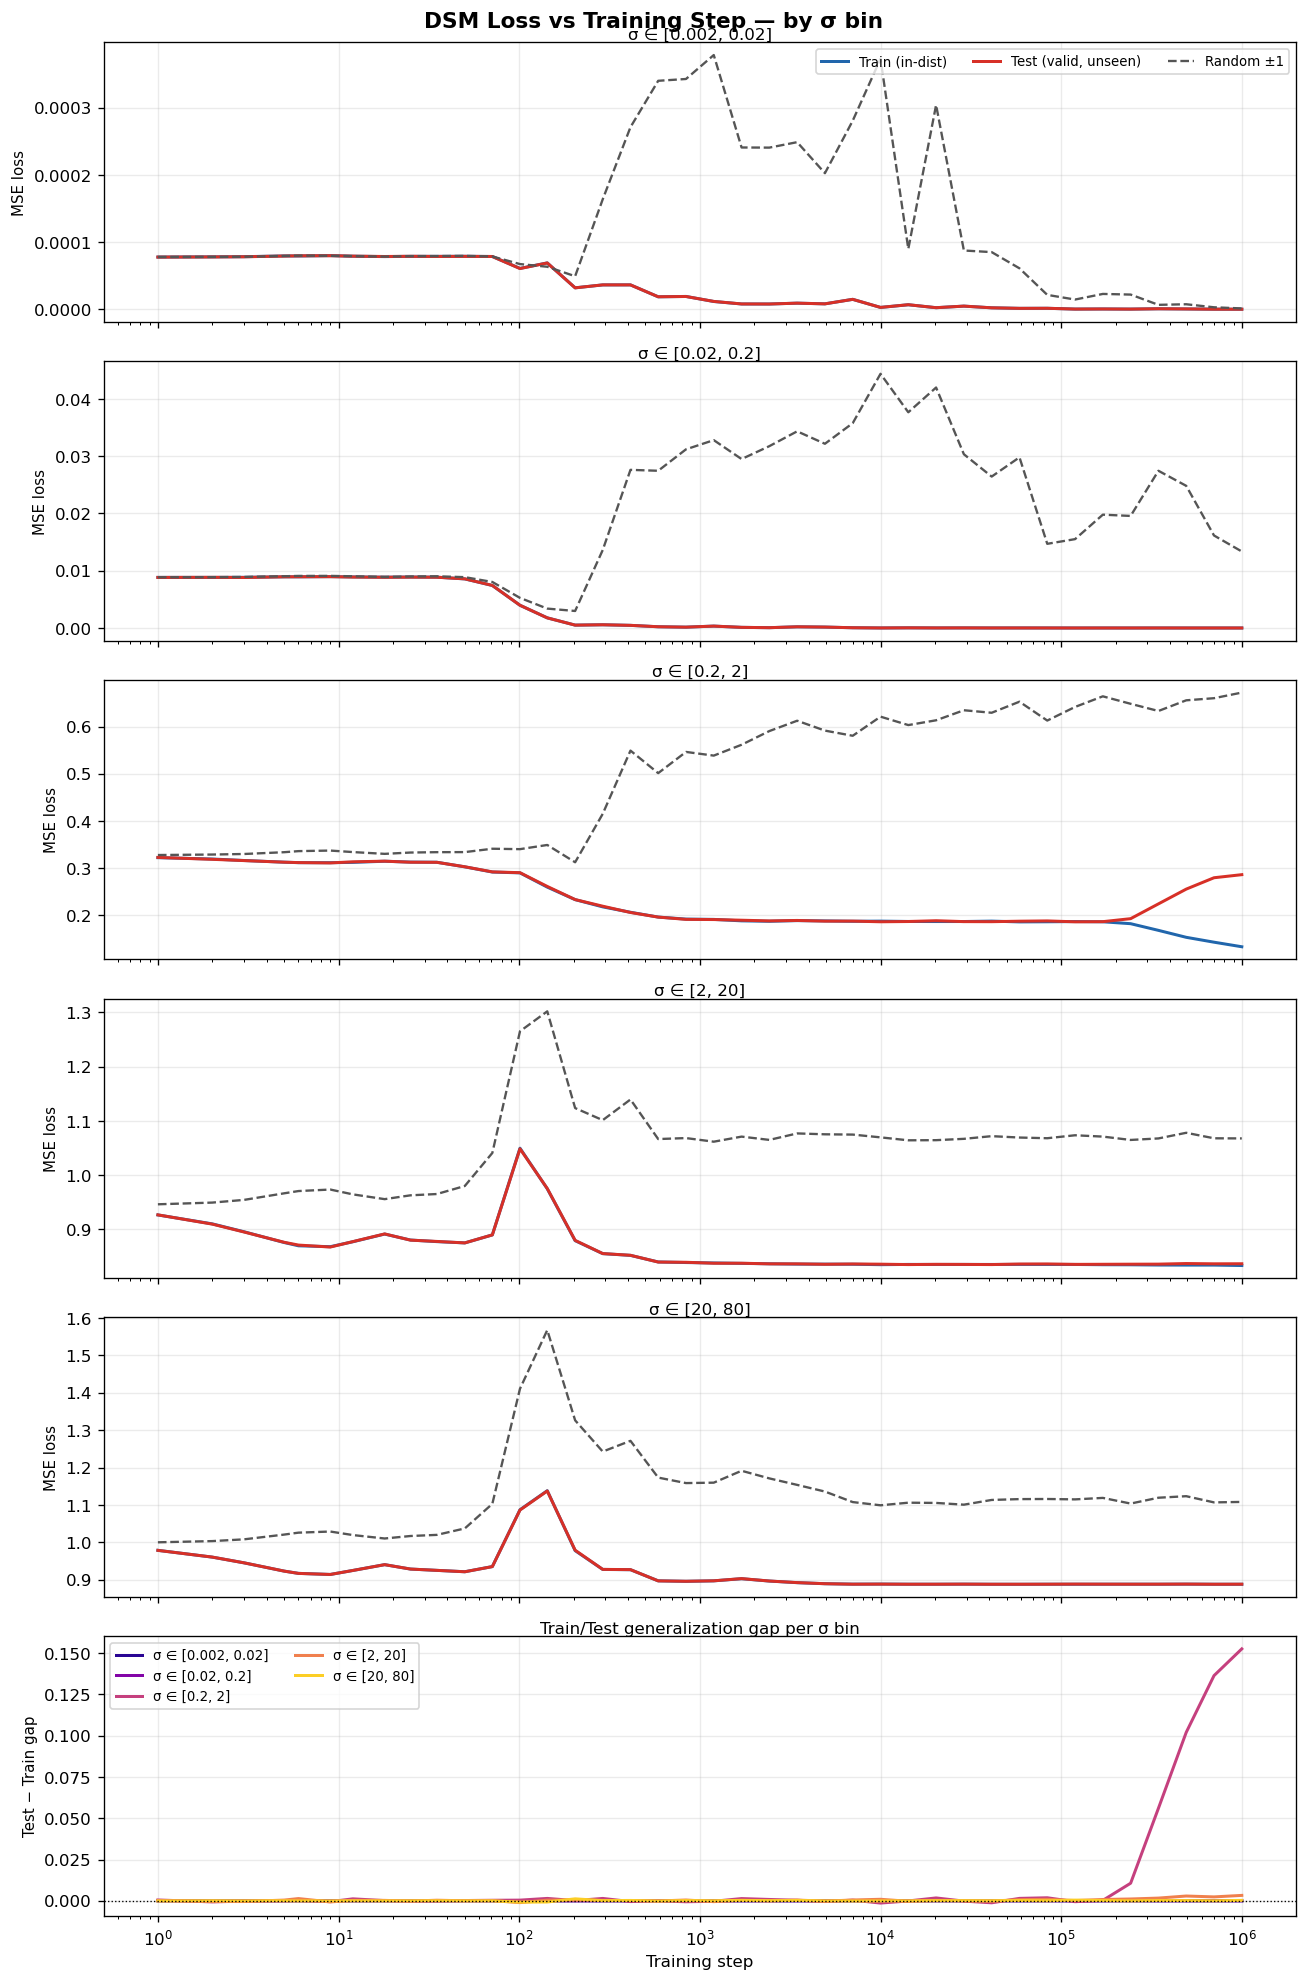

In [4]:
def plot_evolution(exp_names, labels, log_loss=False, save_name=None):
    n_bins = len(SIGMA_BINS)
    colors_exp = plt.cm.tab10(np.linspace(0, 0.9, len(exp_names)))
    fig, axes = plt.subplots(n_bins + 1, 1, figsize=(11, 2.8 * (n_bins + 1)), sharex=True)
    fig.suptitle("DSM Loss vs Training Step — by σ bin", fontsize=13, fontweight="bold")

    for b_idx, (bin_label, smin, smax) in enumerate(SIGMA_BINS):
        ax = axes[b_idx]
        for ei, exp_name in enumerate(exp_names):
            records = all_data[exp_name]
            if not records:
                continue
            steps = np.array([r["epoch"] for r in records])
            sigma_grid = records[0]["sigma_grid"]
            for split in ["train", "test", "random"]:
                vals = np.array([bin_mean(r[f"loss_{split}"], sigma_grid, smin, smax) for r in records])
                style = SPLIT_STYLES[split].copy()
                if len(exp_names) > 1:
                    style.pop("label", None)
                    style["color"] = colors_exp[ei]
                    if split == "test":   style["ls"] = "--"
                    elif split == "random": style["ls"] = ":"
                    lbl = f"{labels[ei]} {split}" if b_idx == 0 else None
                else:
                    lbl = style.pop("label") if b_idx == 0 else style.pop("label", None)
                mask = ~np.isnan(vals)
                steps_plot = steps[mask] + 1
                fn = ax.semilogy if log_loss else ax.plot
                fn(steps_plot, vals[mask], **style, label=lbl)
        ax.set_xscale("log"); ax.set_ylabel("MSE loss", fontsize=9)
        ax.set_title(bin_label, fontsize=10, pad=2); ax.grid(alpha=0.25)
        if b_idx == 0:
            ax.legend(loc="upper right", fontsize=8, ncol=3 if len(exp_names) == 1 else 2)

    ax_gap = axes[-1]
    bin_colors = plt.cm.plasma(np.linspace(0.05, 0.9, n_bins))
    for b_idx, (bin_label, smin, smax) in enumerate(SIGMA_BINS):
        for ei, exp_name in enumerate(exp_names):
            records = all_data[exp_name]
            if not records:
                continue
            steps = np.array([r["epoch"] for r in records])
            sg = records[0]["sigma_grid"]
            gap = np.array([bin_mean(r["loss_test"], sg, smin, smax) - bin_mean(r["loss_train"], sg, smin, smax)
                            for r in records])
            mask = ~np.isnan(gap)
            lbl = bin_label if (len(exp_names) == 1 or ei == 0) else None
            ax_gap.plot((steps+1)[mask], gap[mask], color=bin_colors[b_idx],
                        lw=1.8 if len(exp_names)==1 else 1.4,
                        ls="-" if ei==0 else "--", label=lbl)
    ax_gap.set_xscale("log"); ax_gap.set_ylabel("Test − Train gap", fontsize=9)
    ax_gap.set_title("Train/Test generalization gap per σ bin", fontsize=10, pad=2)
    ax_gap.set_xlabel("Training step", fontsize=10)
    ax_gap.legend(loc="upper left", fontsize=8, ncol=2); ax_gap.grid(alpha=0.25)
    ax_gap.axhline(0, color="k", lw=0.8, ls=":")
    plt.tight_layout()
    if SAVE_FIGS and save_name:
        for ext in ["png", "pdf"]:
            fig.savefig(os.path.join(FIGDIR, f"{save_name}.{ext}"), dpi=150, bbox_inches="tight")
    plt.show()

plot_evolution(["DiT_mini_rowK2_n6_N4096"], ["rowK2"], save_name="evolution_rowK2")

## 2. Single-run evolution: log-y scale

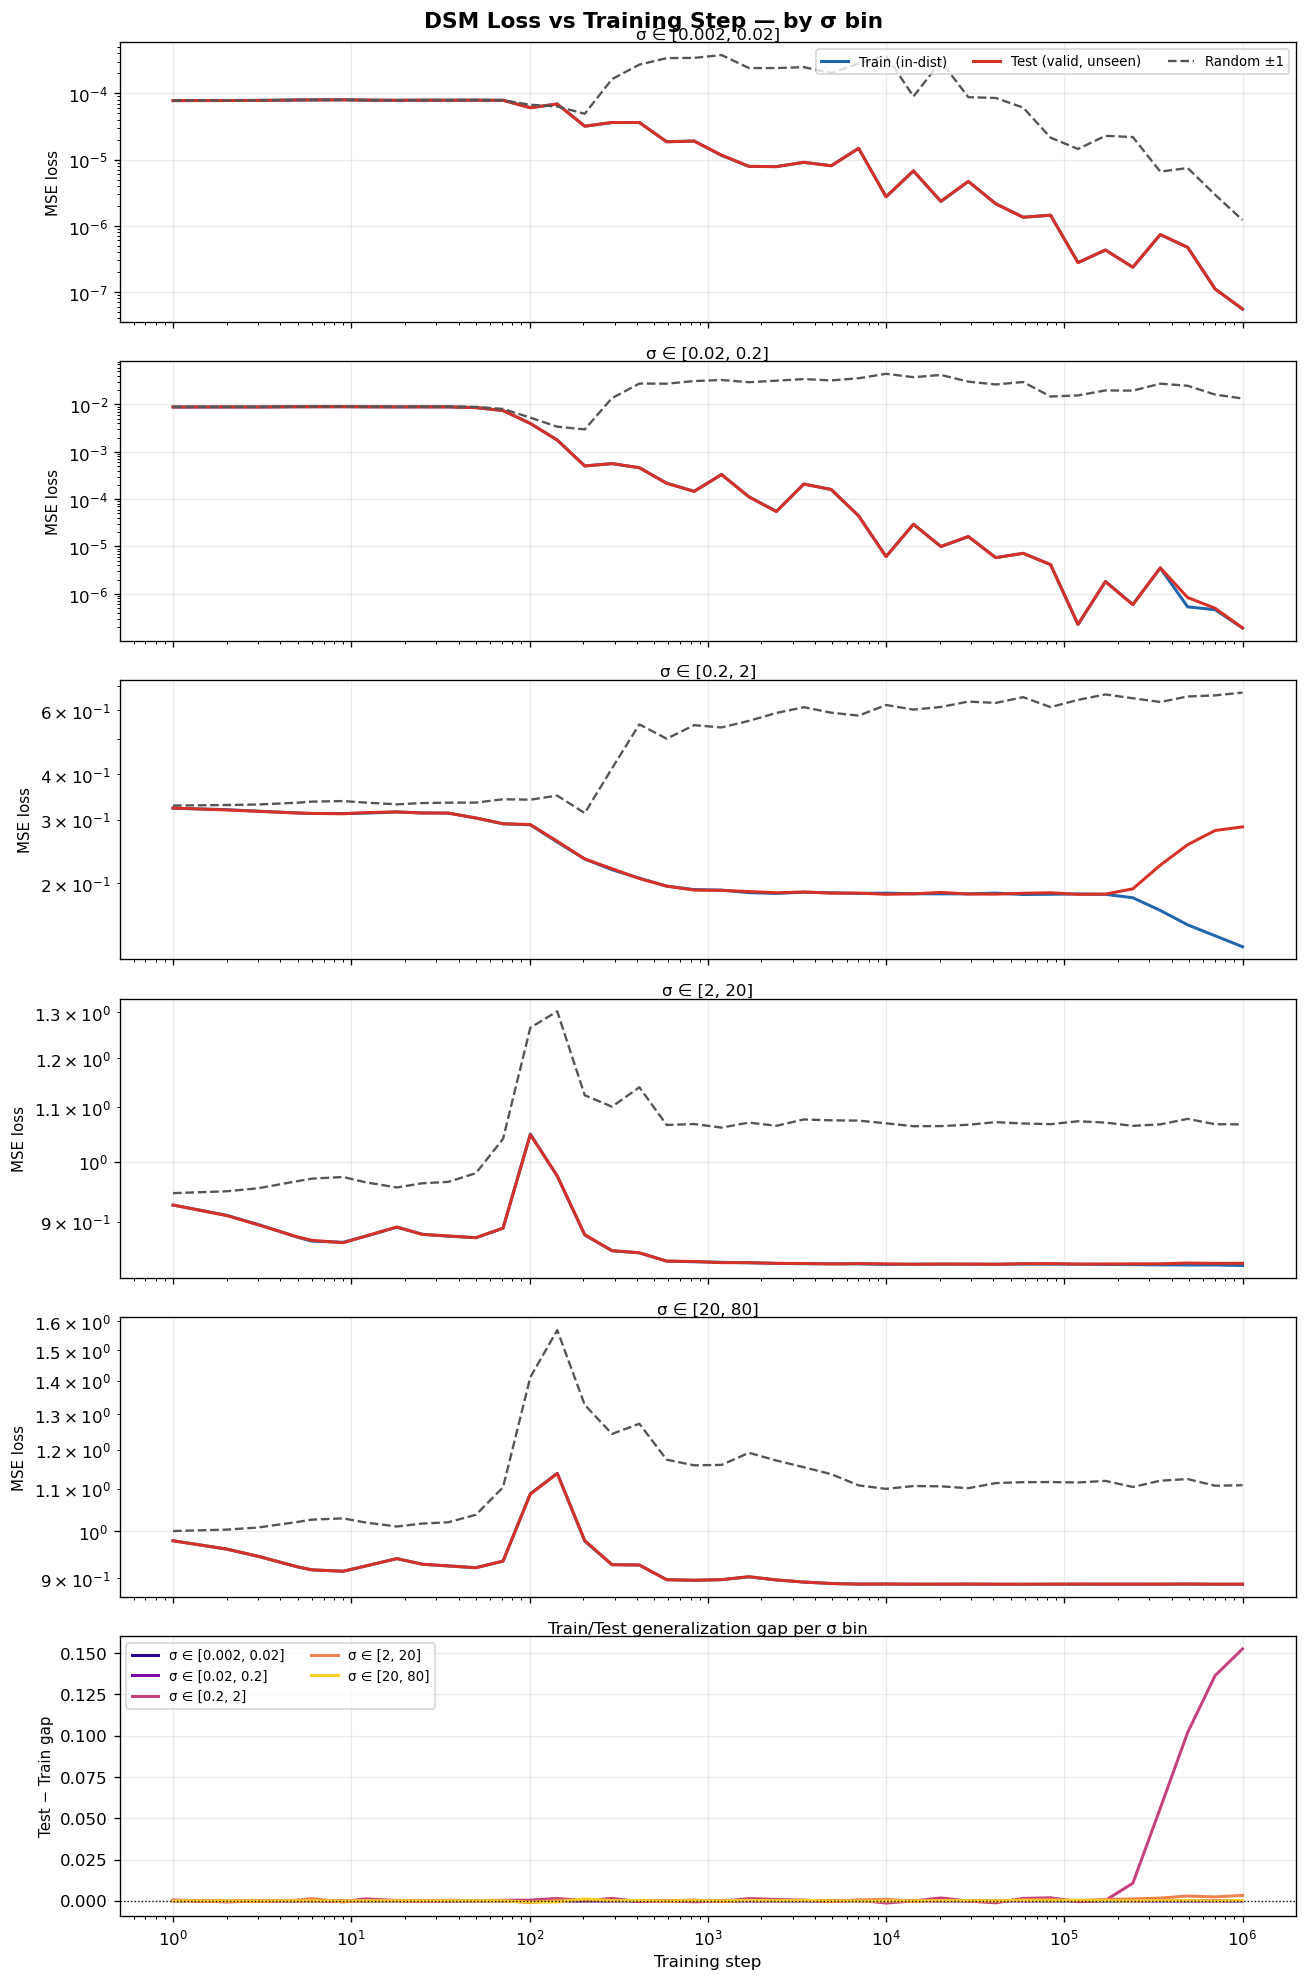

In [5]:
plot_evolution(["DiT_mini_rowK2_n6_N4096"], ["rowK2"], log_loss=True, save_name="evolution_rowK2_logy")

## 3. Zoom: σ ∈ [0.2, 2] — fine sub-bins for rowK2

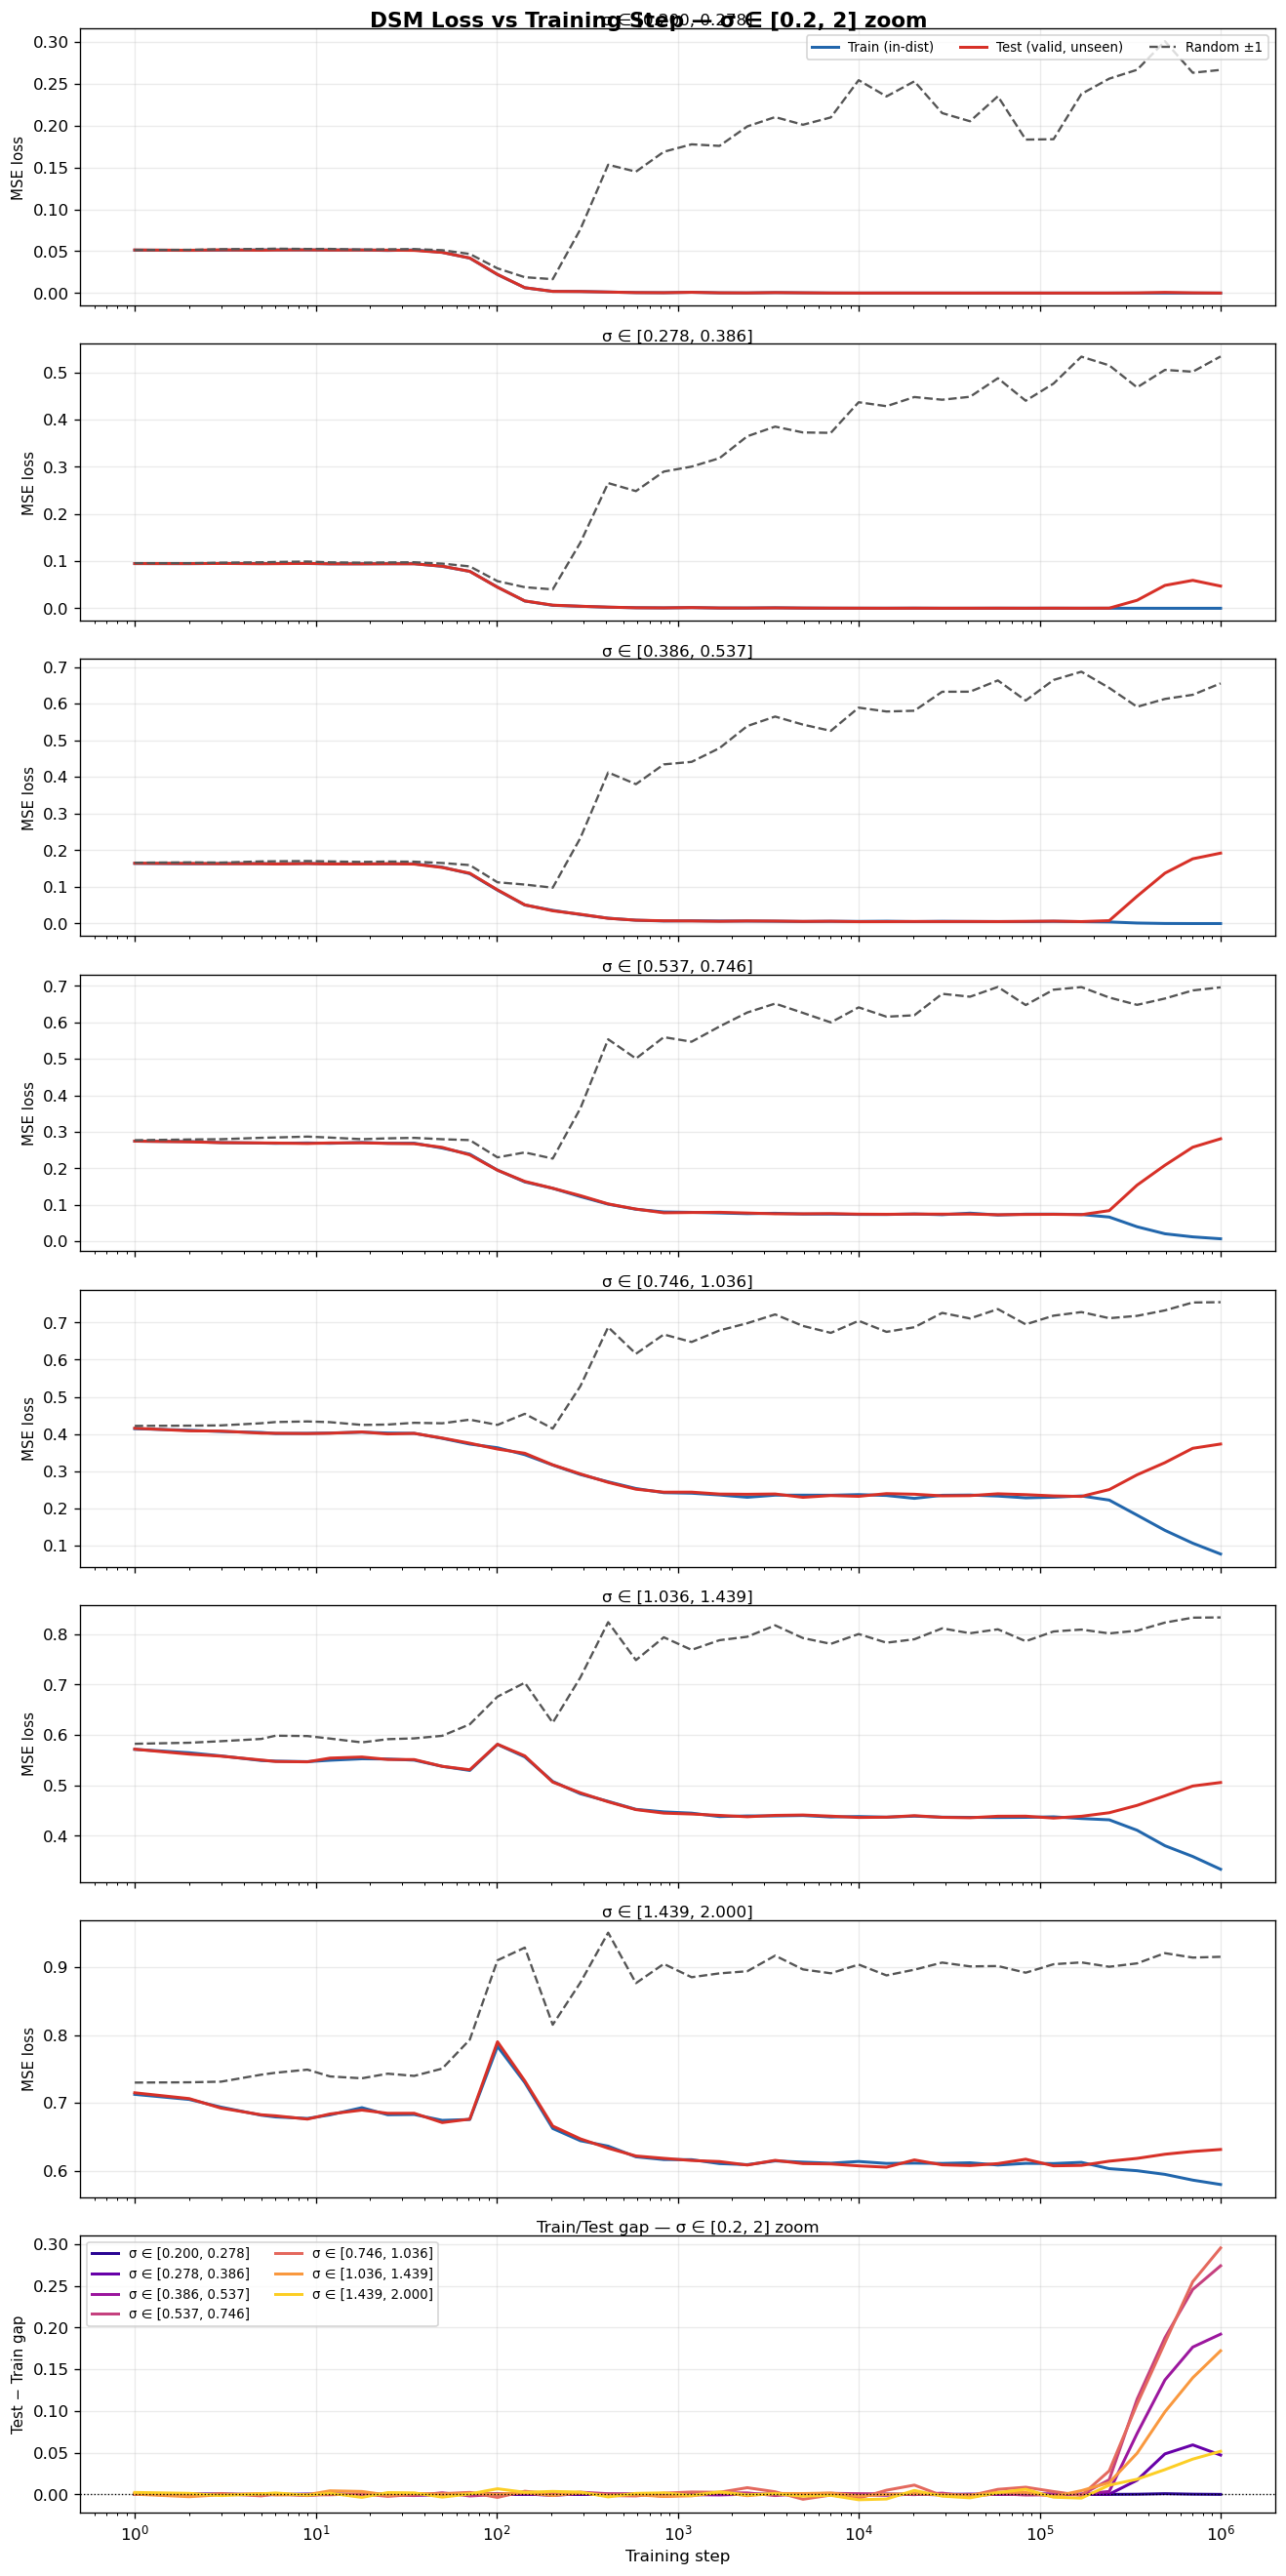

In [6]:
def plot_zoom_bin(exp_names, labels, log_loss=False, save_name=None):
    n_bins = len(SIGMA_BINS_ZOOM)
    colors_exp = plt.cm.tab10(np.linspace(0, 0.9, len(exp_names)))
    fig, axes = plt.subplots(n_bins + 1, 1, figsize=(11, 2.8 * (n_bins + 1)), sharex=True)
    fig.suptitle("DSM Loss vs Training Step — σ ∈ [0.2, 2] zoom", fontsize=13, fontweight="bold")

    for b_idx, (bin_label, smin, smax) in enumerate(SIGMA_BINS_ZOOM):
        ax = axes[b_idx]
        for ei, exp_name in enumerate(exp_names):
            records = all_data[exp_name]
            if not records:
                continue
            steps = np.array([r["epoch"] for r in records])
            sg = records[0]["sigma_grid"]
            for split in ["train", "test", "random"]:
                vals = np.array([bin_mean(r[f"loss_{split}"], sg, smin, smax) for r in records])
                style = SPLIT_STYLES[split].copy()
                if len(exp_names) > 1:
                    style.pop("label", None)
                    style["color"] = colors_exp[ei]
                    if split == "test":    style["ls"] = "--"
                    elif split == "random": style["ls"] = ":"
                    lbl = f"{labels[ei]} {split}" if b_idx == 0 else None
                else:
                    lbl = style.pop("label") if b_idx == 0 else style.pop("label", None)
                mask = ~np.isnan(vals)
                fn = ax.semilogy if log_loss else ax.plot
                fn((steps+1)[mask], vals[mask], **style, label=lbl)
        ax.set_xscale("log"); ax.set_ylabel("MSE loss", fontsize=9)
        ax.set_title(bin_label, fontsize=10, pad=2); ax.grid(alpha=0.25)
        if b_idx == 0:
            ax.legend(loc="upper right", fontsize=8, ncol=3 if len(exp_names)==1 else 2)

    ax_gap = axes[-1]
    bin_colors = plt.cm.plasma(np.linspace(0.05, 0.9, n_bins))
    for b_idx, (bin_label, smin, smax) in enumerate(SIGMA_BINS_ZOOM):
        for ei, exp_name in enumerate(exp_names):
            records = all_data[exp_name]
            if not records:
                continue
            steps = np.array([r["epoch"] for r in records])
            sg = records[0]["sigma_grid"]
            gap = np.array([bin_mean(r["loss_test"], sg, smin, smax) - bin_mean(r["loss_train"], sg, smin, smax)
                            for r in records])
            mask = ~np.isnan(gap)
            lbl = bin_label if (len(exp_names)==1 or ei==0) else None
            ax_gap.plot((steps+1)[mask], gap[mask], color=bin_colors[b_idx],
                        lw=1.8 if len(exp_names)==1 else 1.4,
                        ls="-" if ei==0 else "--", label=lbl)
    ax_gap.set_xscale("log"); ax_gap.set_ylabel("Test − Train gap", fontsize=9)
    ax_gap.set_title("Train/Test gap — σ ∈ [0.2, 2] zoom", fontsize=10, pad=2)
    ax_gap.set_xlabel("Training step", fontsize=10)
    ax_gap.legend(loc="upper left", fontsize=8, ncol=2); ax_gap.grid(alpha=0.25)
    ax_gap.axhline(0, color="k", lw=0.8, ls=":")
    plt.tight_layout()
    if SAVE_FIGS and save_name:
        for ext in ["png", "pdf"]:
            fig.savefig(os.path.join(FIGDIR, f"{save_name}.{ext}"), dpi=150, bbox_inches="tight")
    plt.show()

plot_zoom_bin(["DiT_mini_rowK2_n6_N4096"], ["rowK2"], save_name="zoom_bin_rowK2")

## 4. All 8 row-K runs — evolution comparison

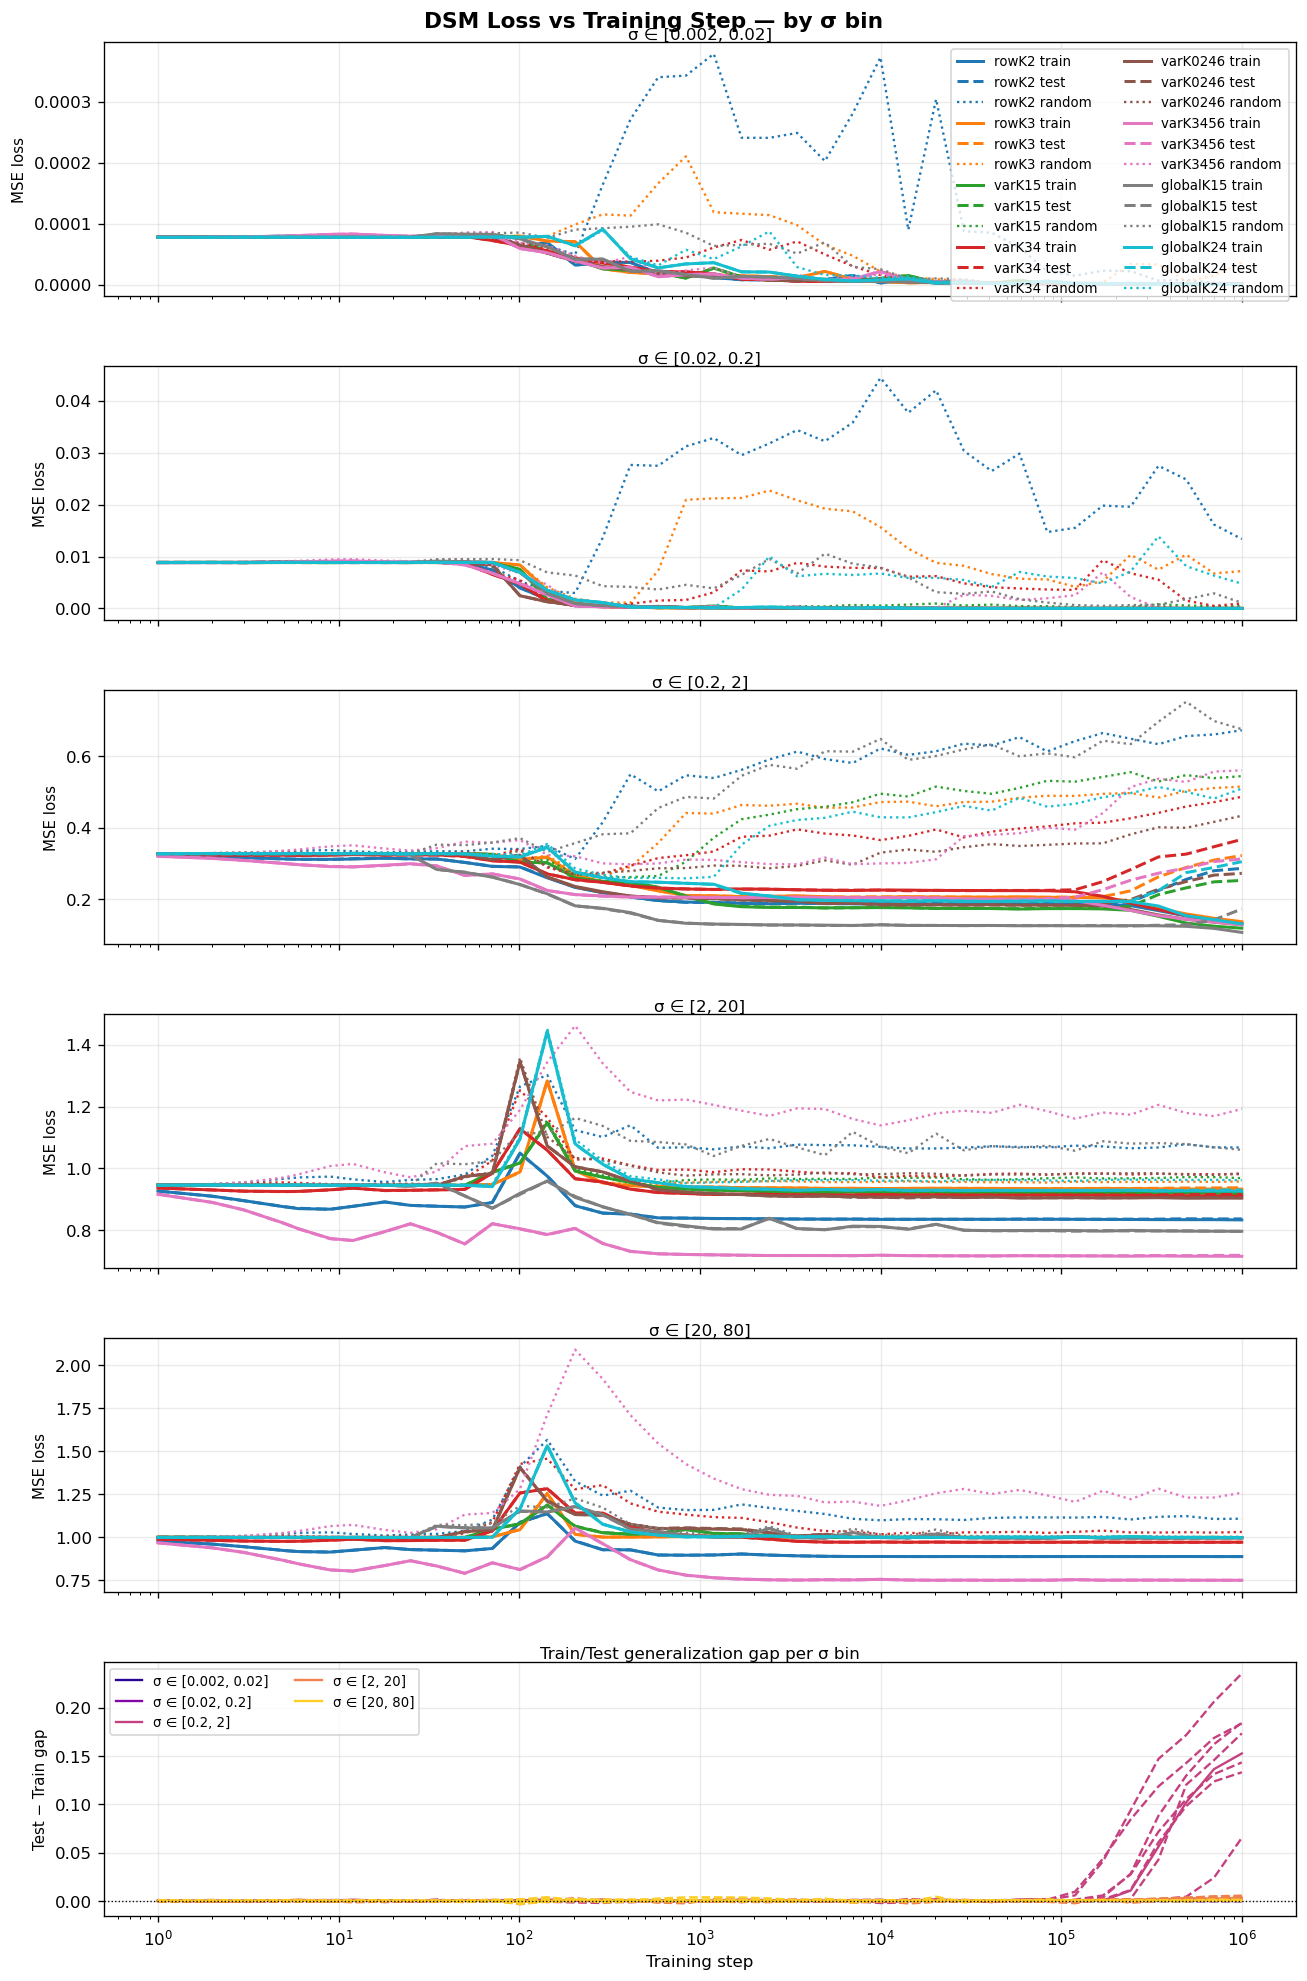

In [7]:
plot_evolution(ALL_EXPS, ALL_LABELS, save_name="evolution_all_rowK")

## 5. Loss vs σ curves at specific checkpoints

Rows = time points (before divergence / just after / final).  
Columns = experiments.

In [8]:
def _draw_sigma_panel(ax, rec, label):
    sigma = rec["sigma_grid"]
    all_line_vals = []
    for split in ["train", "test", "random"]:
        style = SPLIT_STYLES[split].copy()
        lbl = style.pop("label")
        line_vals = rec[f"loss_{split}"]
        ax.plot(sigma, line_vals, **style, label=lbl)
        all_line_vals.append(line_vals)
        lo = np.maximum(line_vals - rec[f"std_{split}"], 1e-9)
        hi = line_vals + rec[f"std_{split}"]
        ax.fill_between(sigma, lo, hi, alpha=0.12, color=style["color"])
    ax.set_xscale("log"); ax.set_yscale("log")
    all_vals = np.concatenate(all_line_vals)
    valid = all_vals[all_vals > 0]
    if len(valid):
        ax.set_ylim(valid.min() * 0.5, valid.max() * 3)
    ax.set_title(f"{label}  (ep {rec['epoch']:,})", fontsize=9)
    ax.set_xlabel("σ", fontsize=8); ax.set_ylabel("MSE loss", fontsize=8)
    ax.legend(fontsize=6, loc="upper left"); ax.grid(alpha=0.25)


def plot_final_sigma_curves(exp_names, labels, which_idx=None, title_suffix="", save_name=None):
    """which_idx: list of checkpoint indices (negative = from end)."""
    if which_idx is None:
        which_idx = [-1]
    n_exp, n_time = len(exp_names), len(which_idx)
    fig, axes = plt.subplots(n_time, n_exp, figsize=(4.2*n_exp, 3.5*n_time), squeeze=False)
    fig.suptitle(f"DSM Loss vs σ{title_suffix}", fontsize=13, fontweight="bold")
    for ti, widx in enumerate(which_idx):
        for ei, (exp_name, label) in enumerate(zip(exp_names, labels)):
            ax = axes[ti][ei]
            records = all_data[exp_name]
            if not records:
                ax.set_visible(False); continue
            try:
                _draw_sigma_panel(ax, records[widx], label)
            except IndexError:
                ax.text(0.5, 0.5, "idx OOB", transform=ax.transAxes, ha="center")
    plt.tight_layout()
    if SAVE_FIGS and save_name:
        for ext in ["png", "pdf"]:
            fig.savefig(os.path.join(FIGDIR, f"{save_name}.{ext}"), dpi=150, bbox_inches="tight")
    plt.show()

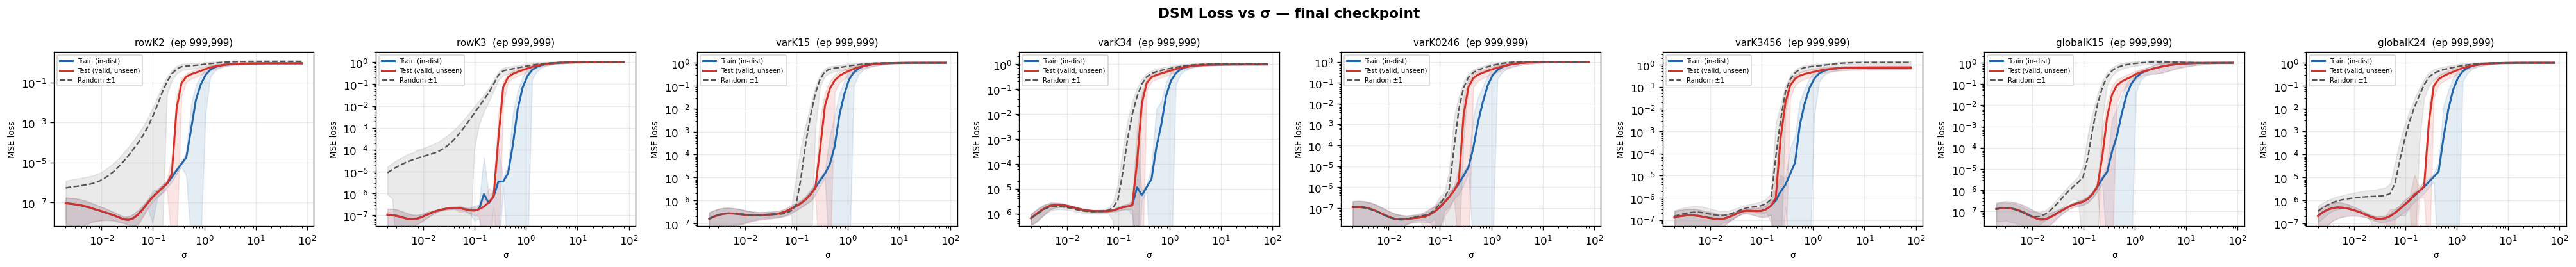

In [9]:
# Final checkpoint only
plot_final_sigma_curves(ALL_EXPS, ALL_LABELS, which_idx=[-1],
                        title_suffix=" — final checkpoint",
                        save_name="sigma_curves_final")

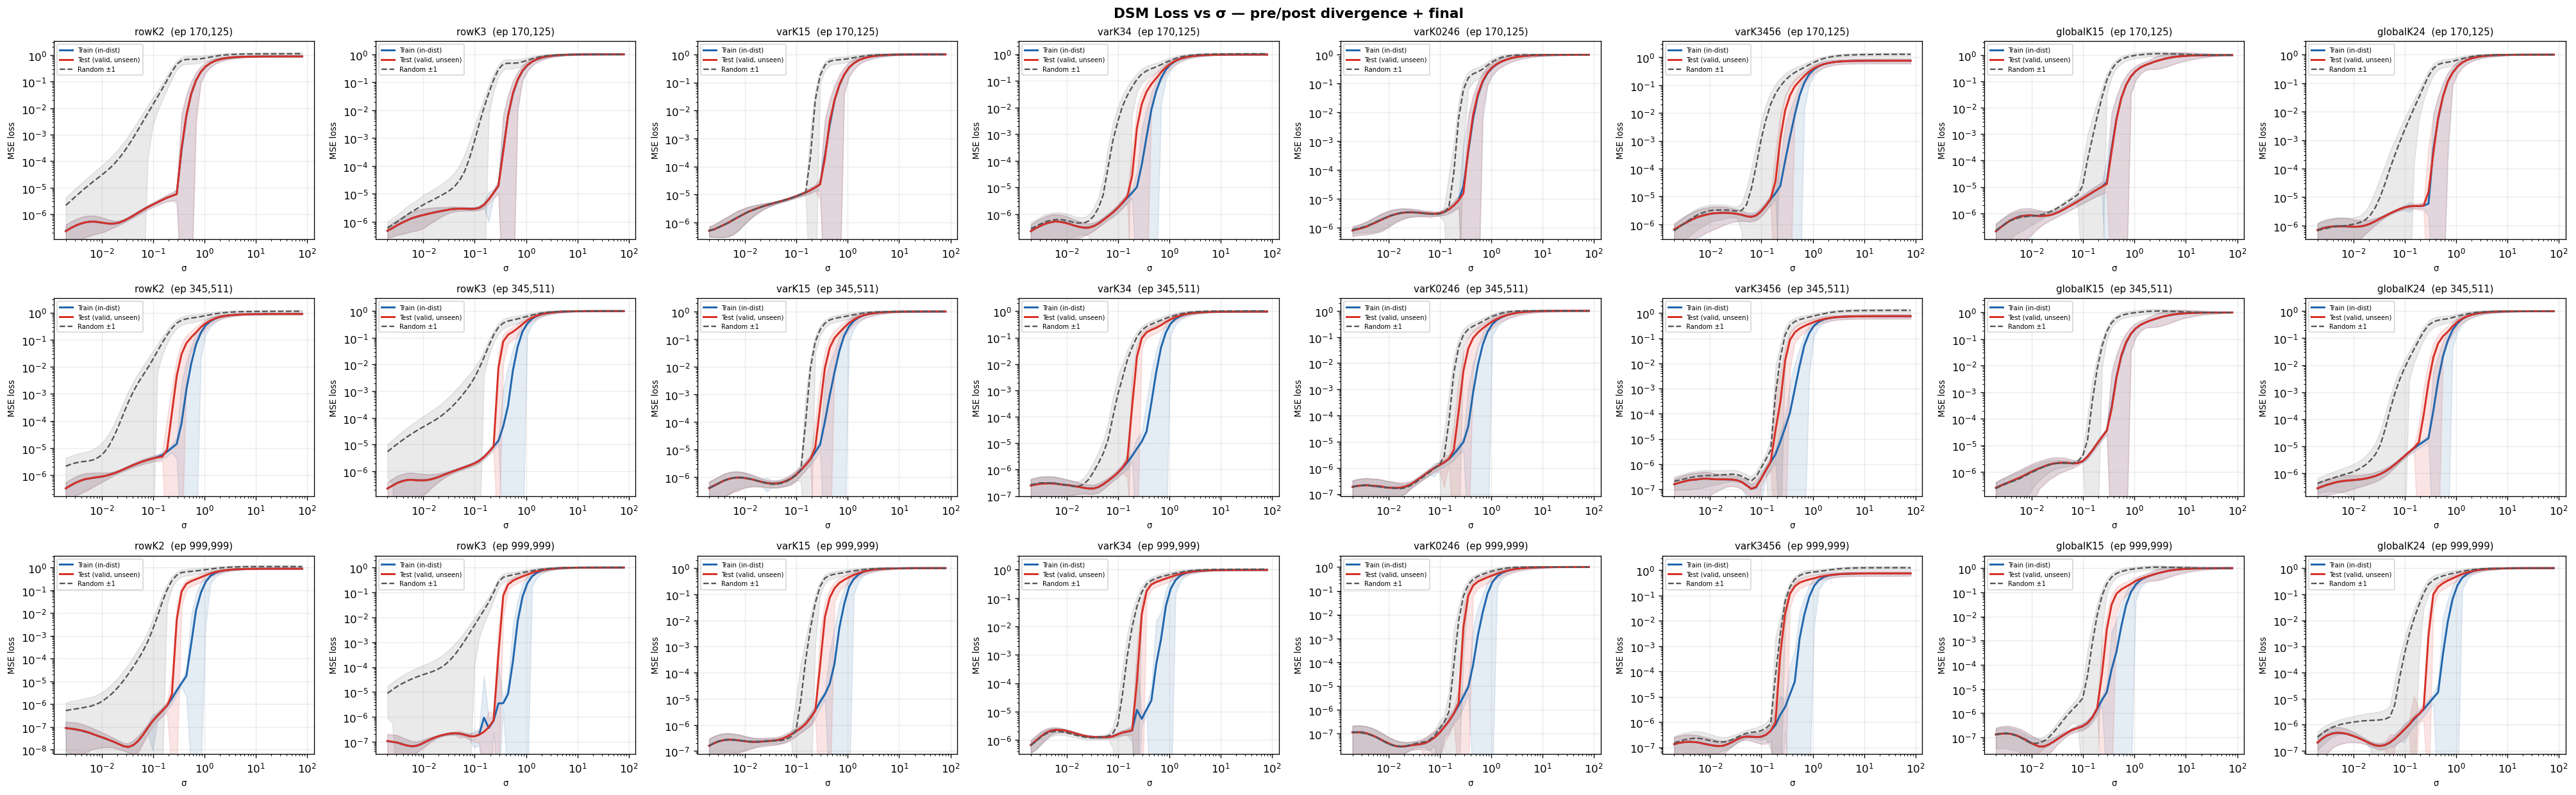

In [10]:
# Three time points: before / just after / final divergence
# idx 33=ep170k (pre), idx 35=ep345k (just after), idx 38=ep999k (final)
plot_final_sigma_curves(ALL_EXPS, ALL_LABELS, which_idx=[33, 35, 38],
                        title_suffix=" — pre/post divergence + final",
                        save_name="sigma_curves_multicheckpoint")

In [11]:
# Inspect gap trajectory for rowK2 to find exact divergence index
records_k2 = all_data["DiT_mini_rowK2_n6_N4096"]
gaps = []
for r in records_k2:
    sg = r["sigma_grid"]
    mask = (sg >= 0.2) & (sg <= 2.0)
    gaps.append((r["epoch"], float((r["loss_test"][mask] - r["loss_train"][mask]).mean())))

print(f"{'idx':>4}  {'epoch':>8}  {'gap':>10}")
for i, (ep, g) in enumerate(gaps):
    marker = " ◄" if g > 0.01 else ""
    print(f"{i:4d}  {ep:8d}  {g:10.4f}{marker}")

 idx     epoch         gap
   0         0      0.0005
   1         1     -0.0007
   2         2     -0.0002
   3         4      0.0000
   4         5      0.0002
   5         8     -0.0005
   6        11      0.0012
   7        17      0.0001
   8        24     -0.0002
   9        34     -0.0001
  10        49      0.0002
  11        70      0.0003
  12       100      0.0004
  13       142      0.0014
  14       203      0.0001
  15       289      0.0014
  16       412     -0.0005
  17       587     -0.0001
  18       837     -0.0006
  19      1193     -0.0003
  20      1701      0.0013
  21      2424      0.0008
  22      3455      0.0003
  23      4923     -0.0005
  24      7017      0.0004
  25     10000     -0.0014
  26     14251     -0.0001
  27     20309      0.0017
  28     28942     -0.0002
  29     41246     -0.0012
  30     58780      0.0015
  31     83767      0.0018
  32    119377     -0.0005
  33    170125      0.0003
  34    242446      0.0106 ◄
  35    345511      0.0560